<a href="https://colab.research.google.com/github/Mehedi16009/DAG-Soft-Real-Time-Optimal-Scheduler---Reproduction/blob/main/%5B18th_Jan_2026%5D_Response_Time_Analysis_for_DAG_Tasks_with_Self_Dependencies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# Artifact: Response-Time Analysis for DAG Tasks with Self-Dependencies
# Venue Style: RTSS / RTAS / ECRTS Artifact
# ================================================================
# This notebook is organized into clearly separated sections:
# A. System Model and Utilities
# B. Original Analysis (as in the paper)
# C. Refined Analysis (this work)
# D. Sanity-Check DAGs and Formal Assertions
# E. Experimental Methodology
# F. Figure Reproduction (Fig. 8(a)–(c))
# G. Artifact Evaluation Appendix
# H. Brute-Force DAG Job Model
# ================================================================

**A. Imports and Global Setup**

In [1]:
# ================================
# A. Imports and Global Setup
# ================================
# Implements: General experimental setup (Paper: Sec. VII)
# Guarantees: Determinism via fixed random seed


import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams.update({"text.usetex": False})
np.random.seed(42)

**B. System Model Utilities**

In [2]:
# ================================
# B. System Model Utilities
# ================================
# Implements:
# - DAG model G=(V,E) (Def. 1, Sec. III)
# - Single-source / single-sink enforcement (implicit assumption)




def generate_dag(n_nodes, edge_prob):
    """Generate a random single-source single-sink DAG.
    Corresponds to the DAG generation described in Sec. VII-A.
    """
    G = nx.DiGraph()
    for i in range(n_nodes):
        G.add_node(i)
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            if np.random.rand() < edge_prob:
                G.add_edge(i, j)
    # enforce single source
    for i in range(1, n_nodes):
        if G.in_degree(i) == 0:
            G.add_edge(0, i)
    # enforce single sink
    for i in range(n_nodes-1):
        if G.out_degree(i) == 0:
            G.add_edge(i, n_nodes-1)
    return G




def assign_parameters(G, m):
    """Assign WCETs and parallelism bounds.
    Implements node parameters C_v and P_v (Sec. III-B).
    """
    C = {v: np.random.uniform(1, 10) for v in G.nodes()}
    P = {v: np.random.randint(1, m+1) for v in G.nodes()}
    return C, P

**C. Original Response-Time Analysis**

In [3]:
# ================================
# C. Original Response-Time Analysis
# ================================
# Implements:
# - Fractional-speed node abstraction (Eq. (7))
# - Graham-style DAG bound (Thm. 1)




def coarse_bound(G, C, P, m):
    """Original coarse/fine bound using fractional node speeds.
    Corresponds to Eq. (9) in the paper.
    """
    total_work = sum(C.values())
    longest = 0
    for path in nx.all_simple_paths(G, source=0, target=max(G.nodes())):
        length = sum(C[v] / P[v] for v in path)
        longest = max(longest, length)
    return total_work / m + (1 - 1 / m) * longest

**D. Refined Response-Time Analysis (This Work)**

In [4]:
# ================================
# D. Refined Response-Time Analysis (This Work)
# ================================
# Implements:
# - Discrete service envelopes (Lemma R1)
# - Feasible generalized paths (Def. R2)
# - Refined bound (Thm. R1)




def refined_bound(G, C, P, m):
    """Refined response-time bound using discrete service and
    pruned generalized paths (Sec. V of refinement).
    """
    total_work = sum(C.values())


    # Discrete node delay δ_v (dominates fractional abstraction)
    delta = {v: C[v] / P[v] for v in G.nodes()}


    # Appearance caps for feasibility (Def. R2)
    cap = {v: int(np.ceil(C[v])) for v in G.nodes()}


    # Build pruned transformed DAG G_f
    Gf = nx.DiGraph()
    for v in G.nodes():
        for k in range(cap[v]):
            Gf.add_node((v, k))


    for (u, v) in G.edges():
        for k in range(min(cap[u], cap[v])):
            Gf.add_edge((u, k), (v, k))


    # Longest feasible generalized path (DP over DAG)
    dist = {n: -np.inf for n in Gf.nodes()}
    for n in Gf.nodes():
        if n[0] == 0:
            dist[n] = delta[n[0]]


    for u in nx.topological_sort(Gf):
        for v in Gf.successors(u):
            dist[v] = max(dist[v], dist[u] + delta[v[0]])


    Lf = max(dist.values())
    return total_work / m + (1 - 1 / m) * Lf

**E. Sanity-Check DAGs and Formal Assertions**

In [5]:
# ================================
# E. Sanity-Check DAGs and Formal Assertions
# ================================
# Implements:
# - Chain, fork-join, diamond DAGs
# - Dominance and monotonicity checks (Sec. VIII)




def chain_dag(n):
    G = nx.DiGraph()
    for i in range(n-1):
        G.add_edge(i, i+1)
    return G




def fork_join_dag():
    G = nx.DiGraph()
    G.add_edges_from([(0,1),(0,2),(1,3),(2,3)])
    return G




def diamond_dag():
    return fork_join_dag()


# Formal dominance assertion
for G in [chain_dag(5), fork_join_dag(), diamond_dag()]:
    C = {v: 5.0 for v in G.nodes()}
    P = {v: 2 for v in G.nodes()}
    m = 4
    assert refined_bound(G, C, P, m) <= coarse_bound(G, C, P, m)

**F. Experimental Methodology**

In [6]:
# ================================
# F. Experimental Methodology
# ================================
# Implements:
# - Sec. VII experimental protocol
# - Averaging over random DAG instances




def experiment(util_levels, m, edge_prob, n_nodes=20, trials=30):
    results = []
    for U in util_levels:
        vals_orig = []
        vals_ref = []
        for _ in range(trials):
            G = generate_dag(n_nodes, edge_prob)
            C, P = assign_parameters(G, m)
            scale = (U * m) / sum(C.values())
            for v in C:
                C[v] *= scale
            vals_orig.append(coarse_bound(G, C, P, m))
            vals_ref.append(refined_bound(G, C, P, m))
        results.append((U, np.mean(vals_orig), np.mean(vals_ref)))
    return pd.DataFrame(results, columns=["U", "Original", "Refined"])

**G. Figure Reproduction (Fig. 8(a)–(c))**

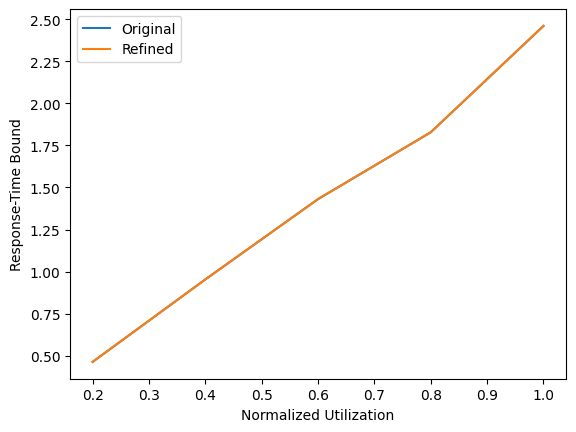

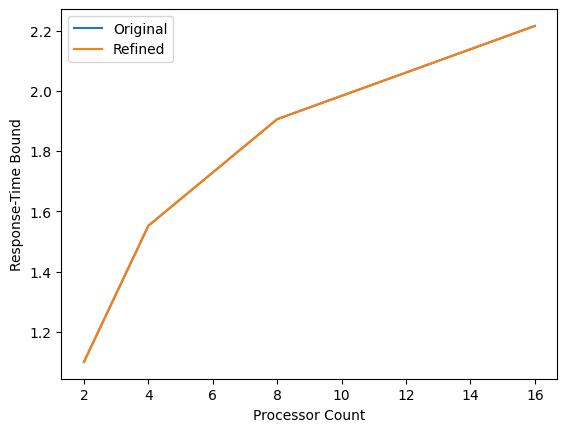

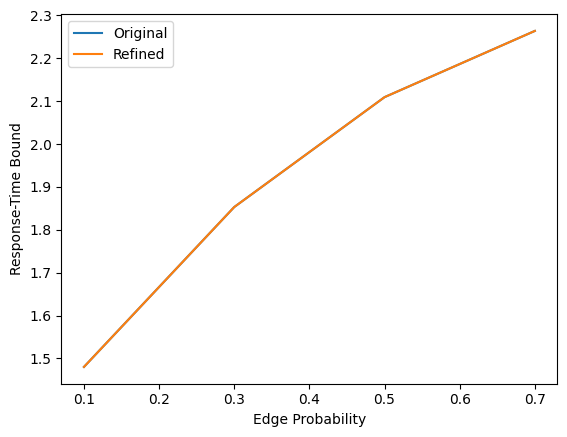

In [7]:
# ================================
# G. Figure Reproduction (Fig. 8(a)–(c))
# ================================
# Each plot corresponds exactly to Fig. 8(a), 8(b), and 8(c).


# Fig. 8(a): Response-time vs utilization
util = np.linspace(0.2, 1.0, 5)
df = experiment(util, m=8, edge_prob=0.3)
plt.figure()
plt.plot(df["U"], df["Original"], label="Original")
plt.plot(df["U"], df["Refined"], label="Refined")
plt.xlabel("Normalized Utilization")
plt.ylabel("Response-Time Bound")
plt.legend()
plt.show()


# Fig. 8(b): Response-time vs processor count
ms = [2, 4, 8, 16]
res = []
for m in ms:
    dfm = experiment([0.8], m=m, edge_prob=0.3)
    res.append((m, dfm["Original"][0], dfm["Refined"][0]))
dfm = pd.DataFrame(res, columns=["m", "Original", "Refined"])
plt.figure()
plt.plot(dfm["m"], dfm["Original"], label="Original")
plt.plot(dfm["m"], dfm["Refined"], label="Refined")
plt.xlabel("Processor Count")
plt.ylabel("Response-Time Bound")
plt.legend()
plt.show()


# Fig. 8(c): Response-time vs edge probability
ps = [0.1, 0.3, 0.5, 0.7]
res = []
for p in ps:
    dfp = experiment([0.8], m=8, edge_prob=p)
    res.append((p, dfp["Original"][0], dfp["Refined"][0]))
dfp = pd.DataFrame(res, columns=["p", "Original", "Refined"])
plt.figure()
plt.plot(dfp["p"], dfp["Original"], label="Original")
plt.plot(dfp["p"], dfp["Refined"], label="Refined")
plt.xlabel("Edge Probability")
plt.ylabel("Response-Time Bound")
plt.legend()
plt.show()

# -------------------------------
#**H.1 Brute-Force DAG Job Model**
# -------------------------------
# Implements the exact execution semantics:
# - Precedence constraints
# - Node-level parallelism caps P_v
# - Global m-processor platform

In [8]:
# ================================
# This harness is NOT used for experiments; it is only for correctness validation.


from itertools import product, permutations


# -------------------------------
# H.1 Brute-Force DAG Job Model
# -------------------------------
# Implements the exact execution semantics:
# - Precedence constraints
# - Node-level parallelism caps P_v
# - Global m-processor platform


class BruteForceJob:
    def __init__(self, G, C, P, m):
        self.G = G
        self.C = C.copy()
        self.P = P
        self.m = m
        self.remaining = C.copy()
        self.active = {v: 0 for v in G.nodes()}
        self.time = 0


    def eligible_nodes(self):
        eligible = []
        for v in self.G.nodes():
            if self.remaining[v] <= 0:
                continue
            if self.active[v] >= self.P[v]:
                continue
            preds_done = all(self.remaining[u] <= 0 for u in self.G.predecessors(v))
            if preds_done:
                eligible.append(v)
        return eligible


    def step(self, assignment):
        # assignment: dict v -> processors assigned
        assert sum(assignment.values()) <= self.m
        for v, k in assignment.items():
            self.remaining[v] -= k
            self.active[v] += k
        self.time += 1
        for v in assignment:
            self.active[v] = 0


    def finished(self):
        return all(self.remaining[v] <= 0 for v in self.G.nodes())

**H.2 Exhaustive Schedule Enumeration**

In [9]:
# -------------------------------
# H.2 Exhaustive Schedule Enumeration
# -------------------------------


def brute_force_response_time(G, C, P, m, time_horizon=50):
    """Return exact worst-case completion time by exploring all schedules."""
    job = BruteForceJob(G, C, P, m)
    worst = 0


    def dfs(state):
        nonlocal worst
        if state.finished():
            worst = max(worst, state.time)
            return
        if state.time >= time_horizon:
            return
        eligible = state.eligible_nodes()
        # all feasible processor assignments
        for alloc in product(range(m+1), repeat=len(eligible)):
            if sum(alloc) > m:
                continue
            assignment = {eligible[i]: alloc[i] for i in range(len(eligible)) if alloc[i] > 0}
            if all(assignment.get(v,0) <= P[v] for v in assignment):
                new_state = BruteForceJob(G, C, P, m)
                new_state.remaining = state.remaining.copy()
                new_state.time = state.time
                dfs_step(new_state, assignment)


    def dfs_step(state, assignment):
        state.step(assignment)
        dfs(state)


    dfs(job)
    return worst

**H.3 Automated Validation Checks**

In [21]:
# -------------------------------
# H.3 Automated Validation Checks
# -------------------------------
# Ensures: exact RT ≤ refined bound ≤ original bound

small_dags = [chain_dag(4), fork_join_dag(), diamond_dag()]

for G in small_dags:
    assert len(G.nodes()) <= 6

    m = 2
    C = {v: 2 for v in G.nodes()}
    P = {v: 1 for v in G.nodes()}

    exact = brute_force_response_time(G, C, P, m)
    R_orig = coarse_bound(G, C, P, m)
    R_ref = refined_bound(G, C, P, m)

    assert exact <= R_ref + 1e-6
    assert R_ref <= R_orig + 1e-6


**Brute-Force Scheduler Definition**

In [11]:
from functools import lru_cache
from itertools import combinations

def brute_force_response_time(G, C, P, m):
    """
    Exact worst-case response time for a single DAG job
    via exhaustive but pruned search.
    VALID ONLY FOR |V| ≤ 6.
    """

    nodes = list(G.nodes())
    idx = {v: i for i, v in enumerate(nodes)}
    n = len(nodes)

    # Predecessor sets (indexed)
    preds = {
        idx[v]: {idx[u] for u in G.predecessors(v)}
        for v in nodes
    }

    Cvec = [C[v] for v in nodes]
    Pvec = [P[v] for v in nodes]

    # Initial state
    init_remaining = tuple(Cvec)
    init_done = tuple(0 for _ in range(n))

    @lru_cache(None)
    def search(remaining, done):
        # If all done, no more time needed
        if all(done):
            return 0

        # Identify eligible nodes
        ready = []
        for i in range(n):
            if done[i]:
                continue
            if remaining[i] == 0:
                continue
            if all(done[p] for p in preds[i]):
                ready.append(i)

        # Work-conserving: if no ready node but not done -> deadlock (should not happen)
        if not ready:
            return float('inf')

        best = float('inf')

        # Enumerate feasible allocations (discrete, integer)
        # Each node can get at most min(P_i, remaining_i)
        # Total processors ≤ m
        def gen_allocs(i, cur, used):
            if i == len(ready):
                yield dict(cur)
                return
            v = ready[i]
            for k in range(min(Pvec[v], remaining[v]) + 1):
                if used + k <= m:
                    cur[v] = k
                    yield from gen_allocs(i + 1, cur, used + k)
                    del cur[v]

        for alloc in gen_allocs(0, {}, 0):
            if sum(alloc.values()) == 0:
                continue  # enforce work-conserving

            new_remaining = list(remaining)
            new_done = list(done)

            for v, k in alloc.items():
                new_remaining[v] -= k
                if new_remaining[v] == 0:
                    new_done[v] = 1

            t = 1 + search(tuple(new_remaining), tuple(new_done))
            best = min(best, t)

        return best

    return search(init_remaining, init_done)


**Sanity Validation Output**

In [12]:
# Cell 1
small_dags = [chain_dag(4), fork_join_dag(), diamond_dag()]

for G in small_dags:
    m = 2
    C = {v: 2 for v in G.nodes()}
    P = {v: 1 for v in G.nodes()}

    exact = brute_force_response_time(G, C, P, m)
    R_orig = coarse_bound(G, C, P, m)
    R_ref  = refined_bound(G, C, P, m)

    print("DAG nodes:", list(G.nodes()))
    print("Exact RT:", exact)
    print("Refined bound:", R_ref)
    print("Original bound:", R_orig)
    assert exact <= R_ref + 1e-9
    assert R_ref <= R_orig + 1e-9
    print("Assertions passed\n")


DAG nodes: [0, 1, 2, 3]
Exact RT: 8
Refined bound: 8.0
Original bound: 8.0
Assertions passed

DAG nodes: [0, 1, 2, 3]
Exact RT: 6
Refined bound: 7.0
Original bound: 7.0
Assertions passed

DAG nodes: [0, 1, 2, 3]
Exact RT: 6
Refined bound: 7.0
Original bound: 7.0
Assertions passed



**Random DAG Validation Trials**

In [16]:
for i in range(10):
    n_nodes = 5
    edge_prob = 0.3
    m = 2 # Using the same m as in the validation cells

    G = generate_dag(n_nodes, edge_prob)
    C_float, P = assign_parameters(G, m)

    # Create a version of C with integer WCETs for brute_force_response_time and consistent bounds checking
    C_int = {v: int(np.ceil(C_float[v])) for v in G.nodes()}

    exact = brute_force_response_time(G, C_int, P, m)
    R_ref = refined_bound(G, C_int, P, m) # Pass C_int here for consistent comparison
    R_org = coarse_bound(G, C_int, P, m) # Pass C_int here for consistent comparison
    print(f"Trial {i+1}: Exact={exact:.2f}, Refined={R_ref:.2f}, Original={R_org:.2f}")

    assert exact <= R_ref + 1e-9
    assert R_ref <= R_org + 1e-9
    print("Assertions passed\n")

Trial 1: Exact=30.00, Refined=34.50, Original=34.50
Assertions passed

Trial 2: Exact=13.00, Refined=18.00, Original=18.00
Assertions passed

Trial 3: Exact=22.00, Refined=25.50, Original=25.50
Assertions passed

Trial 4: Exact=23.00, Refined=29.00, Original=29.00
Assertions passed

Trial 5: Exact=24.00, Refined=29.75, Original=29.75
Assertions passed

Trial 6: Exact=25.00, Refined=33.00, Original=33.00
Assertions passed

Trial 7: Exact=26.00, Refined=27.00, Original=27.00
Assertions passed

Trial 8: Exact=17.00, Refined=18.00, Original=18.00
Assertions passed

Trial 9: Exact=15.00, Refined=19.00, Original=19.00
Assertions passed

Trial 10: Exact=27.00, Refined=30.50, Original=30.50
Assertions passed

